In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import scintools 
import psrsigsim as pss
from scintools.scint_sim import Simulation
import scintools.ththmod as THTH
from astropy import units as u
from scipy.signal import peak_widths
from scipy.interpolate import griddata
import time

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

2026-05-04 18:07:37.855 | DEBUG    | pint.polycos:add_polyco_file_format:629 - Registering Polyco format 'tempo' with mode='rw'


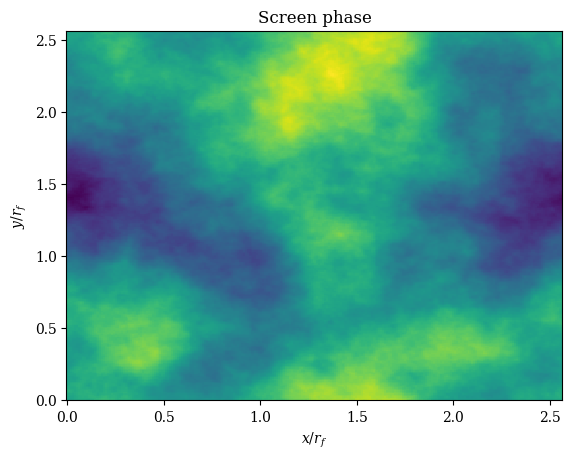

In [2]:
sim = Simulation()
# Plot the simulated phase screen
sim.plot_screen()

In [3]:
help(sim.__init__)

Help on method __init__ in module scintools.scint_sim:

__init__(mb2=2, rf=1, ds=0.01, alpha=1.6666666666666667, ar=1, psi=0, inner=0.001, ns=256, nf=256, dlam=0.25, lamsteps=False, seed=None, nx=None, ny=None, dx=None, dy=None, plot=False, verbose=False, freq=1400, dt=30, mjd=60000, nsub=None, efield=False, noise=None) method of scintools.scint_sim.Simulation instance
    Electromagnetic simulator based on original code by Coles et al. (2010)
    
    mb2: Max Born parameter for strength of scattering
    rf: Fresnel scale
    ds (or dx,dy): Spatial step sizes with respect to rf
    alpha: Structure function exponent (Kolmogorov = 5/3)
    ar: Anisotropy axial ratio
    psi: Anisotropy orientation
    inner: Inner scale w.r.t rf - should generally be smaller than ds
    ns (or nx,ny): Number of spatial steps
    nf: Number of frequency steps.
    dlam: Fractional bandwidth relative to centre frequency
    lamsteps: Boolean to choose whether steps in lambda or freq
    seed: Seed numbe

ds 0.01 ns 4096 time 67.1866250038147


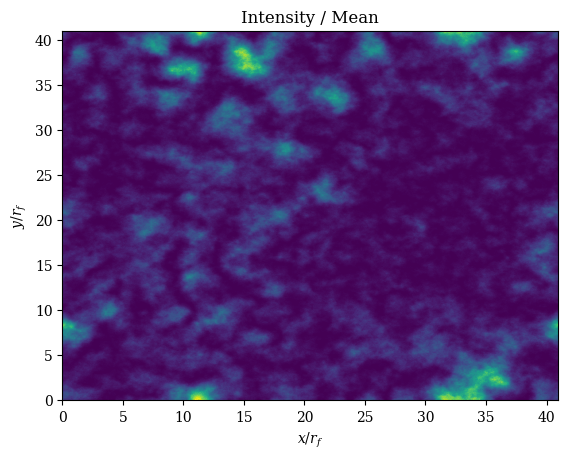

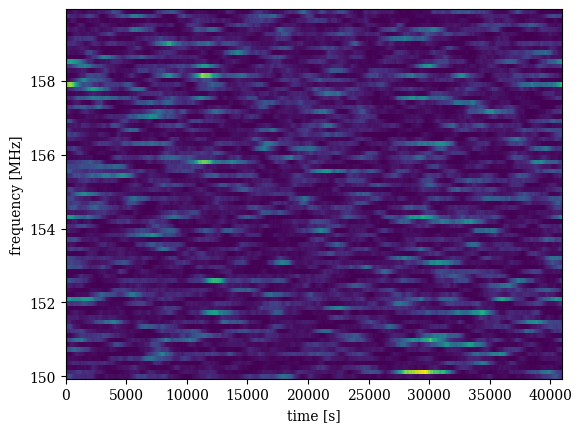

In [21]:
mb2 = 3000 # 0.0002  # the Born variance, which controls the strength of scattering
rf = 1 # per DR: since the simulation is done in 'Fresnel units', this is the unit length and should always be 1
ar = 1  # axial ratio of anisotropy
psi = 0  # angle of velocity relative to the x-axis

dsvec = [0.01]


lf = 150
rf = 160
cf = (lf+rf)/2
bw = rf-lf
frac_bw = bw/cf

dlam = frac_bw  # fractional bandwidth
freq = cf # center frequency
ns = 40*1.024  # The size of the simulation in spatial steps. Total length in refractive scales is ns * ds
# it seems like I can make the scintillation time smaller by tuning down ns
# this is because total length in refractive scales is ns * ds
nf = int(bw/(0.122))  # The number of frequency channels across the dlam fractional bandwidth

dt = 10

seed = 3  # The seed to generate the random phase screen, for reproducible experiments

# these settings produce ~antisymmetric dynamic spectra
# pass rectangular parameters nx, ny to save runtime

for ds in dsvec:
    start = time.time()
    sim = Simulation(mb2=mb2, rf=rf, ar=ar, 
                     ds=ds, 
                     psi=psi, dlam=dlam,
                     #dx=ds, dy=0.2*ds,
                    #ns=int(np.floor(ns/ds)),
                    nx=int(np.floor(ns/ds)),
                    ny=int(np.floor(ns/ds)), nf=nf, seed=seed,
                    freq=freq, dt=dt)
    end = time.time()
    print('ds',ds,'ns',int(np.floor(ns/ds)),'time', end-start)
    dspec = sim.spi
    sim.plot_intensity()
    plt.imshow(dspec.T, aspect='auto', interpolation='none', cmap='viridis', extent=[np.min(sim.times), np.max(sim.times)+sim.times[1]-sim.times[0], np.min(sim.freqs), np.max(sim.freqs)])
    plt.xlabel('time [s]')
    plt.ylabel('frequency [MHz]')
    #plt.colorbar('scintle amplification factor')
    plt.show()
# per NE2025, scattering screen is 38% of the way to the pulsar
# s0 = 1-0.38
# rf = s0 * sqrt(vc/vd)

# ACFs over band to verify that scintools is incorporating the 6/5 power law

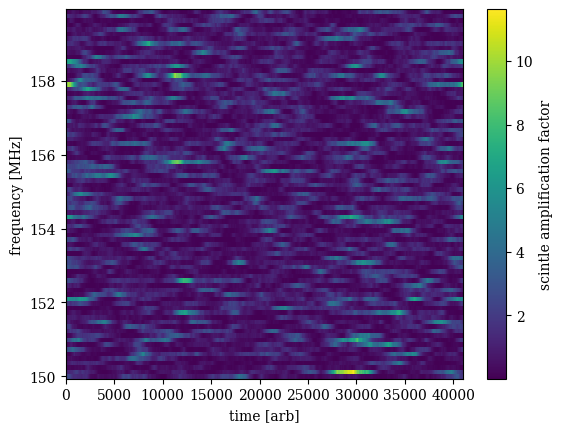

In [19]:
plt.imshow(dspec.T, aspect='auto', interpolation='none', cmap='viridis', extent=[np.min(sim.times), np.max(sim.times)+sim.times[1]-sim.times[0], np.min(sim.freqs), np.max(sim.freqs)])
plt.xlabel('time [arb]')
plt.ylabel('frequency [MHz]')
plt.colorbar(label='scintle amplification factor')
plt.show()

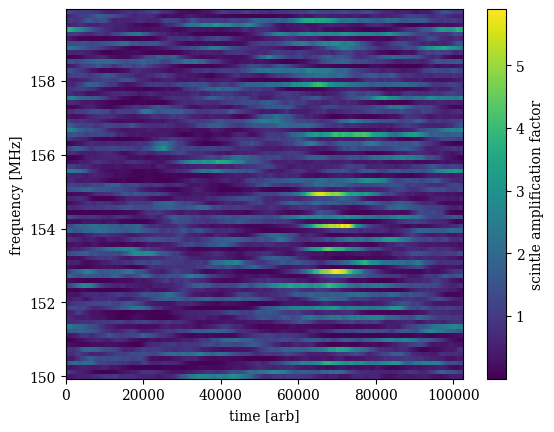

In [12]:
plt.imshow(dspec.T, aspect='auto', interpolation='none', cmap='viridis', extent=[np.min(sim.times), np.max(sim.times)+sim.times[1]-sim.times[0], np.min(sim.freqs), np.max(sim.freqs)])
plt.xlabel('time [arb]')
plt.ylabel('frequency [MHz]')
plt.colorbar(label='scintle amplification factor')
plt.show()

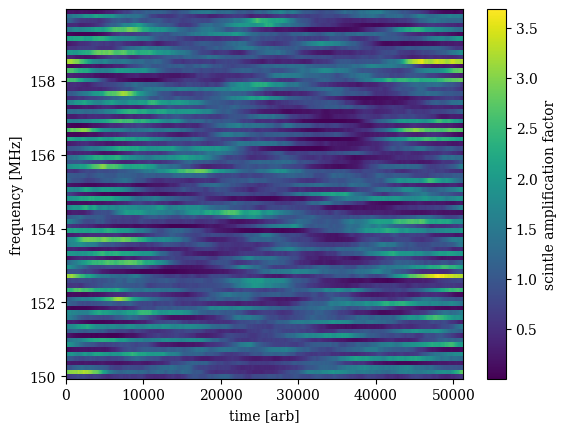

In [10]:
plt.imshow(dspec.T, aspect='auto', interpolation='none', cmap='viridis', extent=[np.min(sim.times), np.max(sim.times)+sim.times[1]-sim.times[0], np.min(sim.freqs), np.max(sim.freqs)])
plt.xlabel('time [arb]')
plt.ylabel('frequency [MHz]')
plt.colorbar(label='scintle amplification factor')
plt.show()

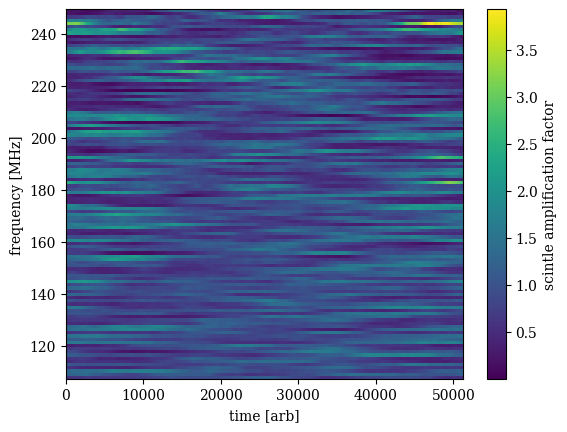

In [8]:
plt.imshow(dspec.T, aspect='auto', interpolation='none', cmap='viridis', extent=[np.min(sim.times), np.max(sim.times)+sim.times[1]-sim.times[0], np.min(sim.freqs), np.max(sim.freqs)])
plt.xlabel('time [arb]')
plt.ylabel('frequency [MHz]')
plt.colorbar(label='scintle amplification factor')
plt.show()

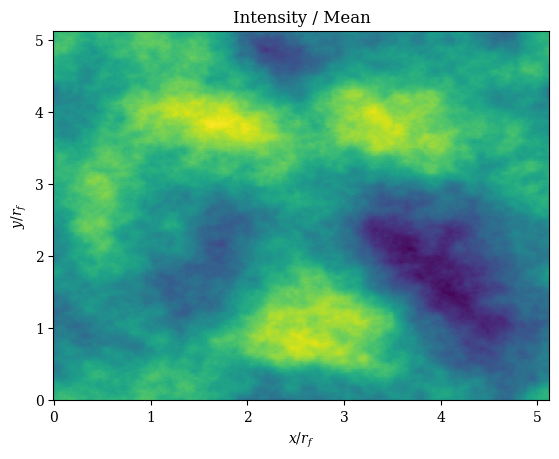

In [260]:
sim.plot_intensity()

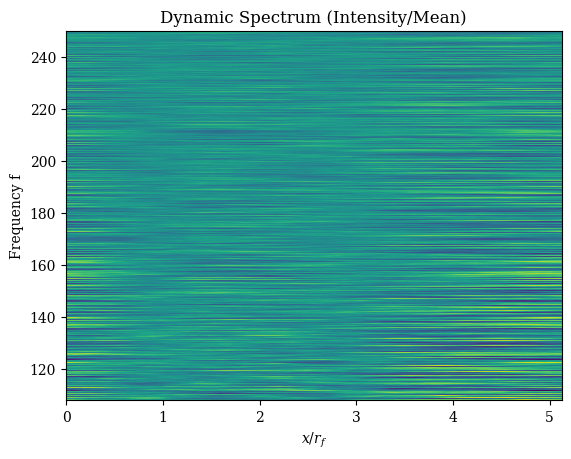

In [261]:
sim.plot_dynspec()

In [262]:
dspechigh = sim.spi

In [264]:
print(dspeclow.shape)
print(dspechigh.shape)

(512, 348)
(512, 1163)


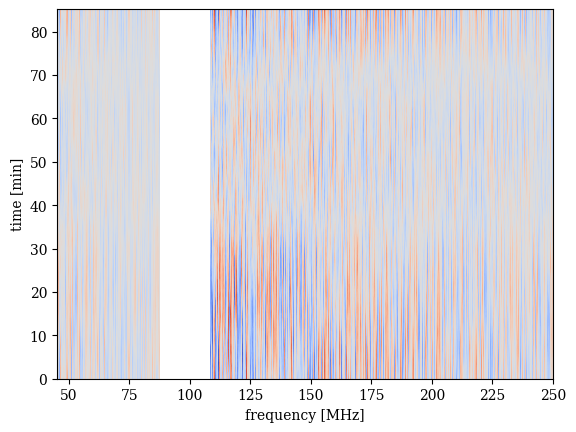

In [272]:
plt.imshow(np.hstack((dspeclow, np.ones((512, int((108-87.5)/0.122)))/np.zeros((512, int((108-87.5)/0.122))), dspechigh)), 
           cmap='coolwarm_r', aspect='auto', interpolation='none', extent=[45, 250, 0, np.max(sim.times)/60])
plt.xlabel('frequency [MHz]')
plt.ylabel('time [min]')
plt.show()

Fresnel scale 0.01


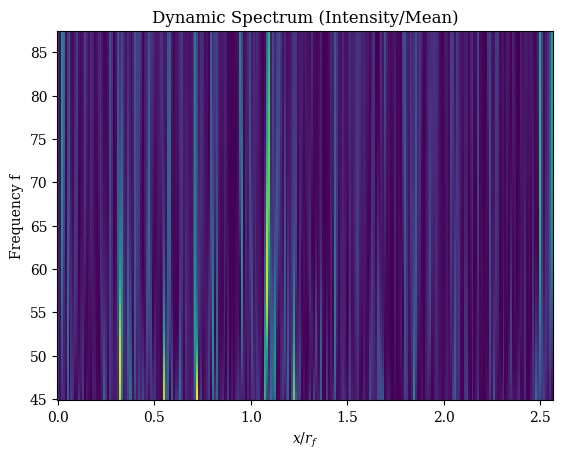

Scintillation bandwidth is 6.73e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 0.169 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 0.016237767391887217


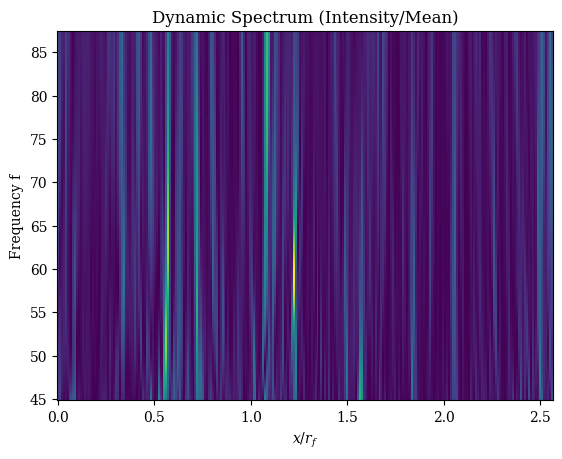

Scintillation bandwidth is 9.2e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 0.253 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 0.026366508987303583


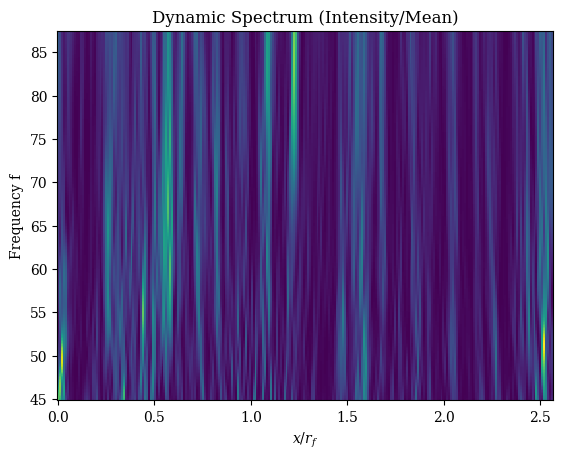

Scintillation bandwidth is 3.09e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 0.479 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 0.04281332398719394


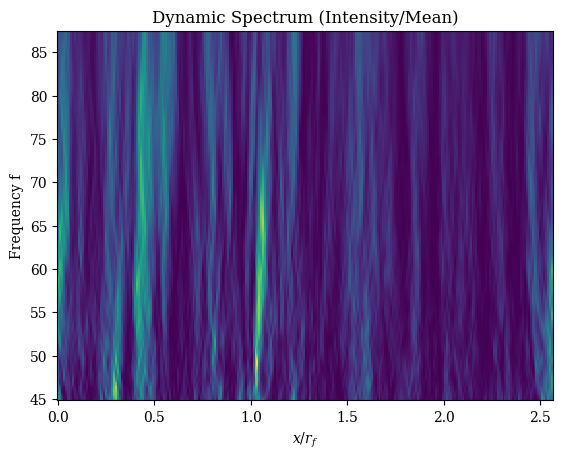

Scintillation bandwidth is 5.45e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 0.903 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 0.06951927961775606


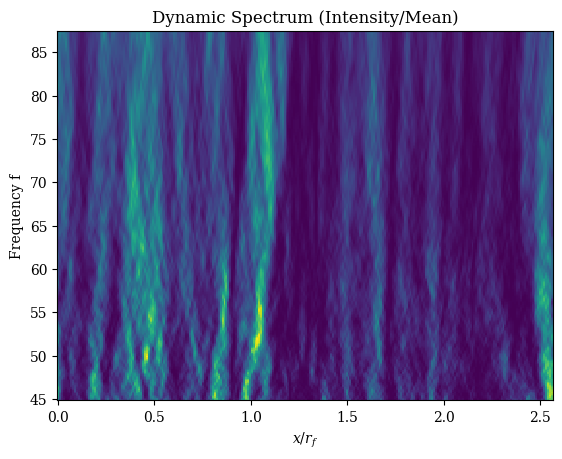

Scintillation bandwidth is 8.92e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 1.62 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 0.11288378916846889


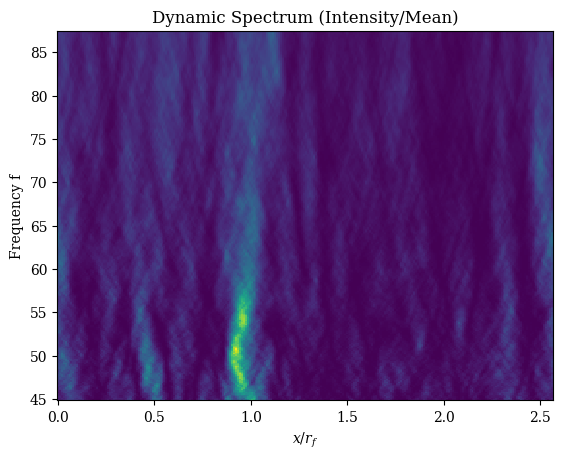

Scintillation bandwidth is 3.81e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 1.91 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 0.18329807108324356


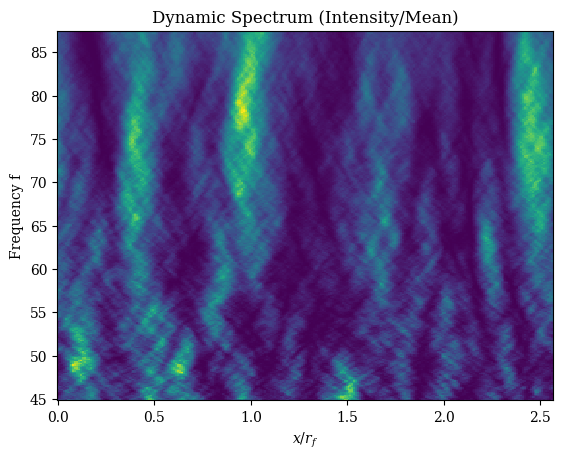

Scintillation bandwidth is 9.9e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 1.92 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 0.29763514416313175


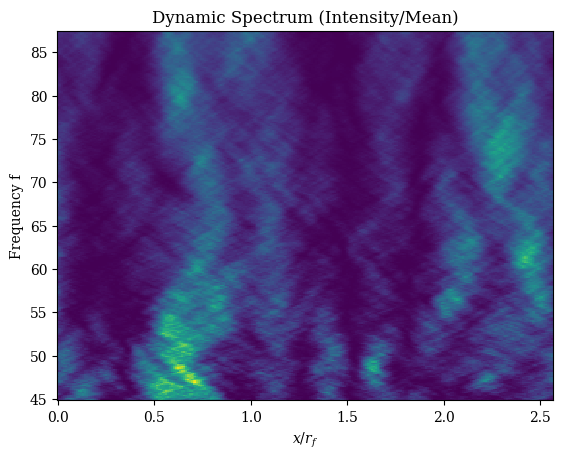

Scintillation bandwidth is 6.05e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 3.73 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 0.4832930238571752


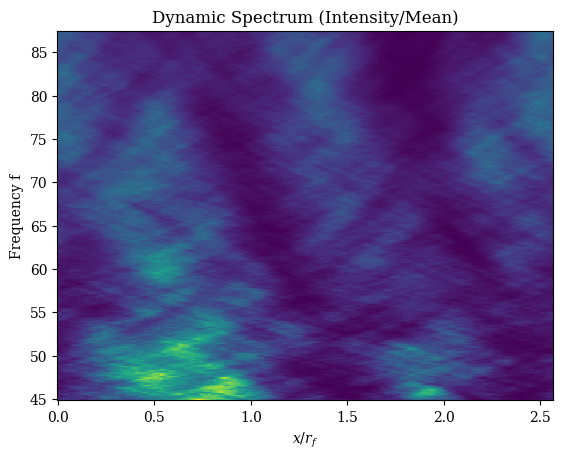

Scintillation bandwidth is 3.63e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 7.54 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 0.7847599703514611


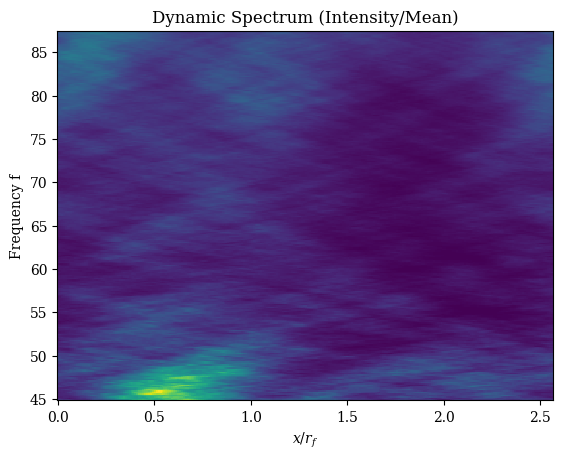

Scintillation bandwidth is 8.02e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 10.6 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 1.2742749857031335


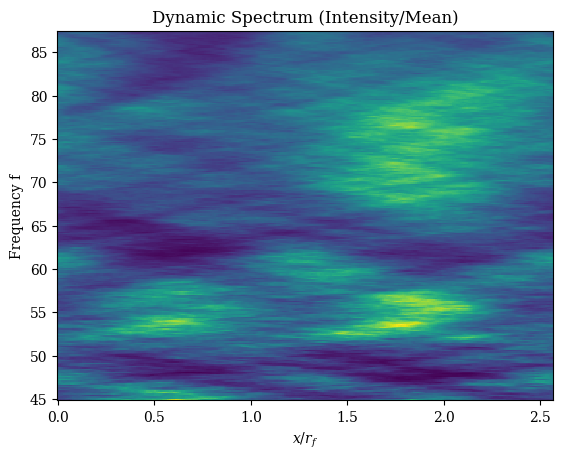

Scintillation bandwidth is 3.81e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 9.97 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 2.06913808111479


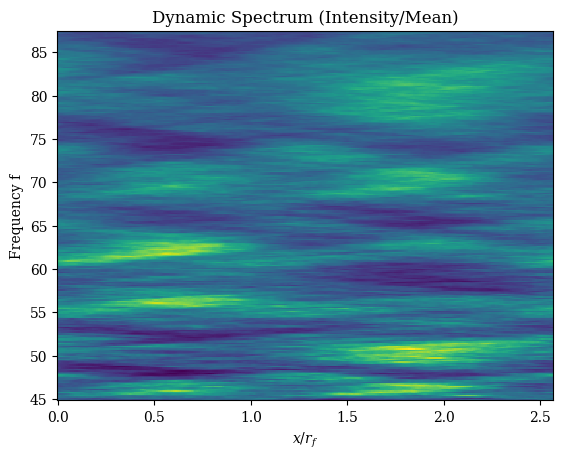

Scintillation bandwidth is 1.32e+03 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 8.16 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 3.359818286283781


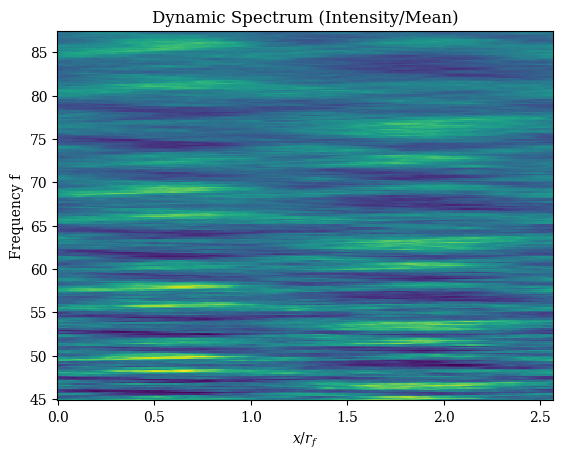

Scintillation bandwidth is 4.77e+02 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 4.98 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 5.455594781168514


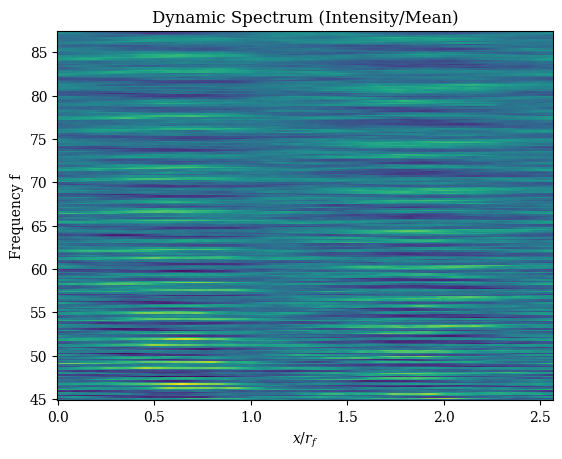

Scintillation bandwidth is 1.78e+02 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 4.3 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 8.858667904100823


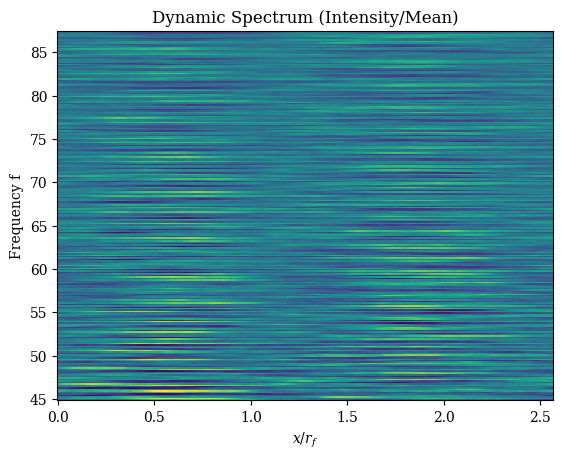

Scintillation bandwidth is 83.3 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 4.9 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 14.38449888287663


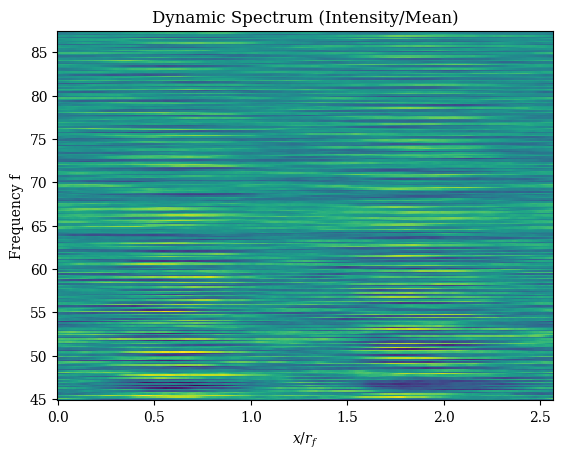

Scintillation bandwidth is 1.08e+02 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 3.33 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 23.357214690901213


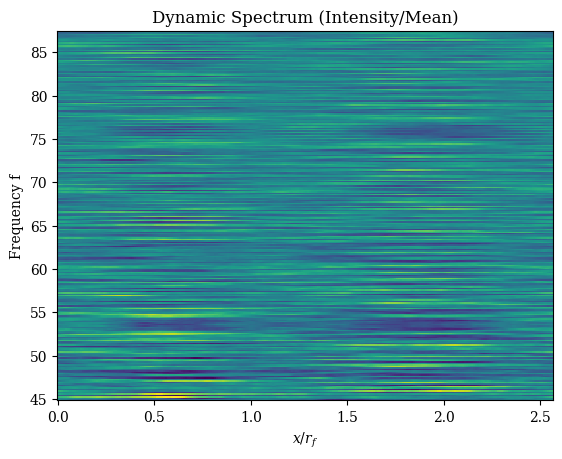

Scintillation bandwidth is 92.8 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 5.49 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 37.92690190732246


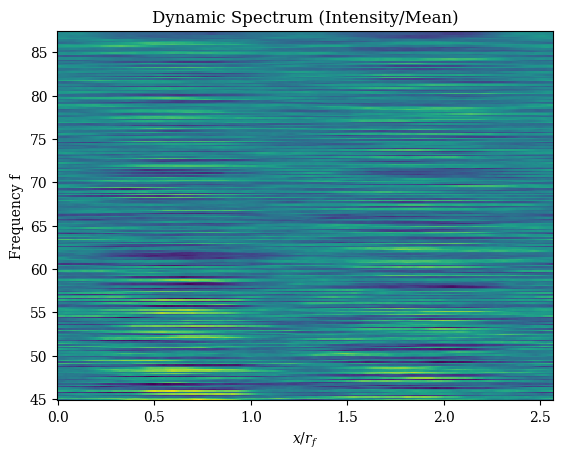

Scintillation bandwidth is 1e+02 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 2.41 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 61.584821106602604


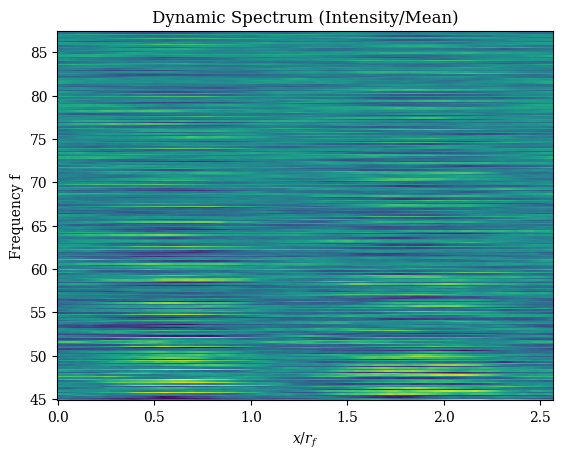

Scintillation bandwidth is 94.6 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 4.73 min
    Note: scint timescale resolution is 0.167 min.
Fresnel scale 100.0


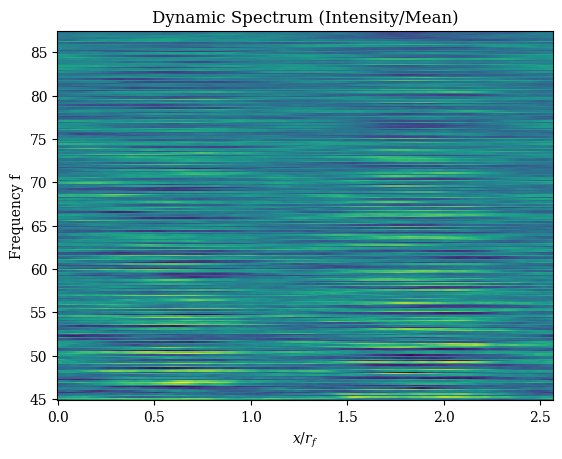

Scintillation bandwidth is 1.02e+02 kHz.
    Note: scint BW resolution is 1.67e+02 kHz.
Scintillation timescale is 4.37 min
    Note: scint timescale resolution is 0.167 min.


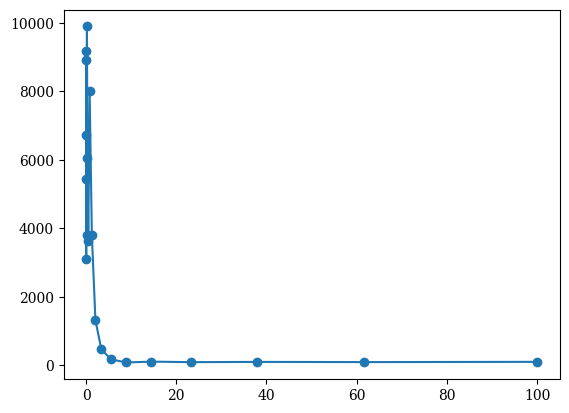

In [112]:
def acf(vec):
    a = []
    for i in range(len(vec)):
        rollvec = np.roll(vec, i)
        a.append(np.dot(vec, rollvec)/len(vec))
    return np.array(a)
def fwhm(x, y):
    w = peak_widths(y, np.where(x==0)[0], rel_height=0.5)[0]
    return w

def run_sim_acfs(mb2=2, rf=1, ar=1, psi=0, fm='below', ns=256, nf=256, dt=10, seed=2):

    if fm == 'below':
        leftf = 45
        rightf = 87.5
    elif fm == 'above':
        leftf = 108
        rightf = 250
    else:
        print('Please choose \'above\' or \'below\' for the fm parameter.')

    cf = (leftf+rightf)/2
    bw = rightf-leftf
    frac_bw = bw/cf

    dlam = frac_bw  # fractional bandwidth
    freq = cf # center frequency

    print(f'Fresnel scale {rf}')

    sim = Simulation(mb2=mb2, rf=rf, ar=ar, psi=psi, dlam=dlam,
                    ns=ns, nf=nf, seed=seed,
                    freq=freq, dt=dt)
    sim.plot_dynspec()
    
    dspec = sim.spi

    spec = np.average(dspec, axis=0)-1
    dv = sim.freqs[1]-sim.freqs[0]
    x = np.arange(len(spec))*dt-len(spec)*dt/2
    y = np.roll(acf(spec), len(spec)//2)
    sbw = fwhm(x, y)[0]*dv*1000/2 # scintillation bandwidth
    print(f'Scintillation bandwidth is {sbw:.3} kHz.')
    print(f'    Note: scint BW resolution is {dv*1000:.3} kHz.')

    time = np.average(dspec, axis=1)-1
    dt = (sim.times[1]-sim.times[0])/60/60
    x = np.arange(len(time))*dt-len(time)*dt/2
    y = np.roll(acf(time), len(time)//2)
    st = fwhm(x, y)[0]*dt*60/2 # scintillation timescale
    print(f'Scintillation timescale is {st:.3} min')
    print(f'    Note: scint timescale resolution is {dt*60:.3} min.')

    return sbw, st

#mb2vec = [0.1, 0.5, 1, 5, 10, 15, 20, 50, 75, 100, 150, 200]
rfvec = np.logspace(-2, 2, 20)
sbwvec = []
stvec = []
for rf in rfvec:
    sbw0, st0 = run_sim_acfs(rf=rf)
    sbwvec.append(sbw0)
    stvec.append(st0)
plt.plot(rfvec, sbwvec, marker='o')
plt.show()

In [225]:
def run_sim_acfs(mb2=2, rf=1, ar=1, psi=0, fm='below', ns=256, nf=256, dt=10, seed=2):

    if fm == 'below':
        leftf = 45
        rightf = 87.5
    elif fm == 'above':
        leftf = 108
        rightf = 250
    else:
        print('Please choose \'above\' or \'below\' for the fm parameter.')

    cf = (leftf+rightf)/2
    bw = rightf-leftf
    frac_bw = bw/cf

    dlam = frac_bw  # fractional bandwidth
    freq = cf # center frequency

    #print(f'Fresnel scale {rf}')

    sim = Simulation(mb2=mb2, rf=rf, ar=ar, psi=psi, dlam=dlam,
                    ns=ns, nf=nf, seed=seed,
                    freq=freq, dt=dt)
    #sim.plot_dynspec()
    
    dspec = sim.spi

    spec = np.average(dspec, axis=0)-1
    dv = sim.freqs[1]-sim.freqs[0]
    x = np.arange(len(spec))*dt-len(spec)*dt/2
    y = np.roll(acf(spec), len(spec)//2)
    sbw = fwhm(x, y)[0]*dv*1000/2 # scintillation bandwidth
    #print(f'Scintillation bandwidth is {sbw:.3} kHz.')
    #print(f'    Note: scint BW resolution is {dv*1000:.3} kHz.')

    time = np.average(dspec, axis=1)-1
    dt = (sim.times[1]-sim.times[0])/60/60
    x = np.arange(len(time))*dt-len(time)*dt/2
    y = np.roll(acf(time), len(time)//2)
    st = fwhm(x, y)[0]*dt*60/2 # scintillation timescale
    #print(f'Scintillation timescale is {st:.3} min')
    #print(f'    Note: scint timescale resolution is {dt*60:.3} min.')

    return sbw, st, dspec

# ONE TRIAL
# mb2vec = np.logspace(-2, 2, 10)
# rfvec = np.logspace(-2, 2, 10)
# nsvec = [128, 128+64, 256, 256+128, 512, 512+256, 1024]
# arr = []
# # for rf in rfvec:
# #     for mb2 in mb2vec:
# #         print(mb2, rf)
# #         sbw0, st0 = run_sim_acfs(mb2=mb2, rf=rf)
# #         arr.append([mb2, rf, sbw0, st0])
# for ns in nsvec:
#     sbw0, st0, dspec = run_sim_acfs(ns=ns)
#     arr.append([sbw0, st0])
# arr = np.array(arr)

# SEVERAL TRIALS
mb2vec = np.logspace(-2, 2, 10)
rfvec = np.logspace(0, 2, 10)
nsvec = [128, 128+64, 256, 256+128, 512, 512+256, 1024, 1024+512, 2048]
big_arr = []
trials = 10
# for t in range(trials):
#     arr = []
#     for rf in rfvec:
#         for mb2 in mb2vec:
#             print(mb2, rf)
#             sbw0, st0 = run_sim_acfs(mb2=mb2, rf=rf, seed=t)
#             arr.append([mb2, rf, sbw0, st0])
#     big_arr.append(arr)
# big_arr = np.array(big_arr)
# print(big_arr.shape)
for t in range(trials):
    arr = []
    for rf in rfvec:
        for ns in nsvec:
            print(t, rf, ns)
            start = time.time()
            sbw0, st0, dspec = run_sim_acfs(rf=rf, ns=ns, seed=t)
            end = time.time()
            print(end-start, 's')
            arr.append([rf, ns, sbw0, st0, end-start])
    arr = np.array(arr)
    big_arr.append(arr)
big_arr = np.array(big_arr)
print(big_arr.shape)

# RANDOM TRIALS
# arr = []
# mb2vec = 10**np.random.uniform(-2, 2, 100)
# rfvec = 10**np.random.uniform(-2, 2, 100)
# print(mb2vec[:5])
# print(rfvec[:5])
# for i in range(100):
#     if i%10==0:
#         print(i)
#     mb2 = mb2vec[i]
#     rf = rfvec[i]
#     sbw0, st0 = run_sim_acfs(mb2=mb2, rf=rf, seed=np.random.randint(0, 100))
#     arr.append([mb2, rf, sbw0, st0])

0 1.0 128
0.1536870002746582 s
0 1.0 192
0.28672099113464355 s
0 1.0 256
0.5493390560150146 s
0 1.0 384
1.4763660430908203 s
0 1.0 512
2.422335147857666 s
0 1.0 768
5.004230976104736 s
0 1.0 1024
10.628124952316284 s
0 1.0 1536
26.69307804107666 s
0 1.0 2048
49.71855306625366 s
0 1.6681005372000588 128
0.14927411079406738 s
0 1.6681005372000588 192
0.3108408451080322 s
0 1.6681005372000588 256
0.5319929122924805 s
0 1.6681005372000588 384
1.3634591102600098 s
0 1.6681005372000588 512
2.5549659729003906 s
0 1.6681005372000588 768
5.192538022994995 s
0 1.6681005372000588 1024
10.963834047317505 s
0 1.6681005372000588 1536
27.020736932754517 s
0 1.6681005372000588 2048
49.86890411376953 s
0 2.7825594022071245 128
0.15258502960205078 s
0 2.7825594022071245 192
0.29387426376342773 s
0 2.7825594022071245 256
0.5302400588989258 s
0 2.7825594022071245 384
1.3102998733520508 s
0 2.7825594022071245 512
2.3785901069641113 s
0 2.7825594022071245 768
5.261491060256958 s
0 2.7825594022071245 1024
11

KeyboardInterrupt: 

In [227]:
big_arr = np.array(big_arr)
print(big_arr.shape)
big_arr = np.squeeze(big_arr)
print(big_arr.shape)
arr = np.average(big_arr, axis=0)

(3, 90, 5)
(3, 90, 5)


166.6666666666643


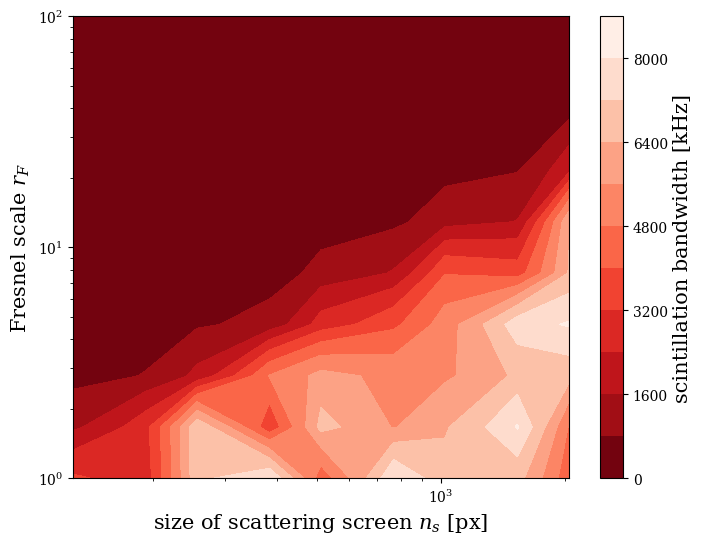

0.16666666666666666


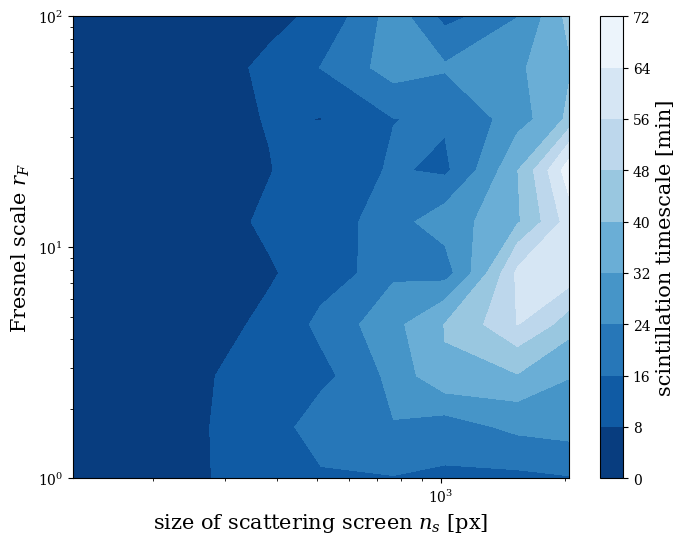

In [230]:
fig = plt.figure(figsize=(8,6))
print(dv*1000)
plt.contourf(nsvec, rfvec, arr[:,2].reshape(len(rfvec), len(nsvec)), levels=10, cmap='Reds_r', vmin=dv*1000)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'size of scattering screen $n_s$ [px]', size=15)
plt.ylabel(r'Fresnel scale $r_F$', size=15)
cbar = plt.colorbar(label='scintillation bandwidth [kHz]')
cbar.set_label('scintillation bandwidth [kHz]', size=15)
plt.show()

fig = plt.figure(figsize=(8,6))
print(dt*60)
plt.contourf(nsvec, rfvec, arr[:,3].reshape(len(rfvec), len(nsvec)), levels=10, cmap='Blues_r', vmin=dt*60)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'size of scattering screen $n_s$ [px]', size=15)
plt.ylabel(r'Fresnel scale $r_F$', size=15)
cbar = plt.colorbar(label='scintillation timescale [min]')
cbar.set_label('scintillation timescale [min]', size=15)
plt.show()

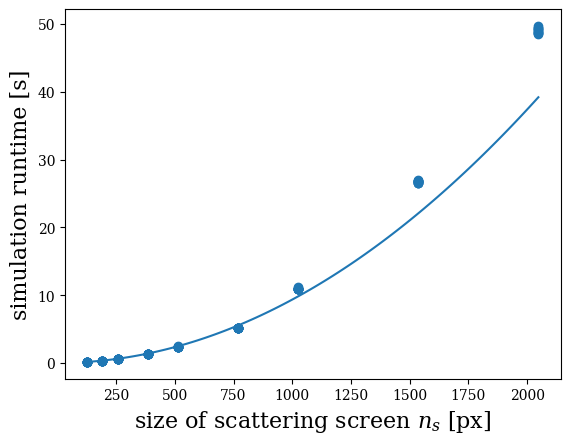

In [251]:
plt.scatter(arr[:,1], arr[:,4])
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('size of scattering screen $n_s$ [px]', size=16)
plt.ylabel('simulation runtime [s]', size=16)
xxx = np.linspace(np.min(arr[:,1]), np.max(arr[:,1]), 100)
p = 10**(2*(np.log10(xxx)-np.log10(np.min(arr[:,1])))-5.5*arr[:,4][np.argmin(arr[:,1])])
plt.plot(xxx, p)
plt.show()

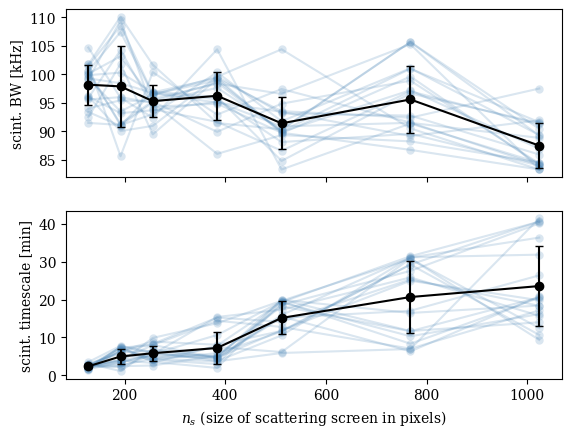

In [208]:
fig, ax = plt.subplots(2, 1, sharex=True)
for a in big_arr:
    ax[0].plot(nsvec, a[:,0], marker='o', color='steelblue', alpha=0.2, mew=0)
    ax[1].plot(nsvec, a[:,1], marker='o', color='steelblue', alpha=0.2, mew=0)
ax[0].errorbar(nsvec, np.average(big_arr, axis=0)[:,0], np.std(big_arr[:,:,0], axis=0), marker='o', capsize=3, color='k')
ax[1].errorbar(nsvec, np.average(big_arr, axis=0)[:,1], np.std(big_arr[:,:,1], axis=0), marker='o', capsize=3, color='k')
ax[0].set_ylabel('scint. BW [kHz]')
ax[1].set_ylabel('scint. timescale [min]')
ax[1].set_xlabel('$n_s$ (size of scattering screen in pixels)')
plt.show()

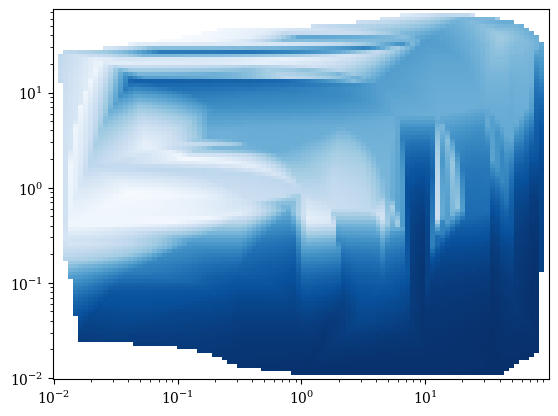

In [168]:
xi = np.logspace(np.log10(mb2vec.min()), np.log10(mb2vec.max()), 100)
yi = np.logspace(np.log10(rfvec.min()), np.log10(rfvec.max()), 100)

Xi, Yi = np.meshgrid(xi, yi)
arr = np.array(arr)

Zi = griddata((mb2vec, rfvec), arr[:,3], (Xi, Yi), method='linear')

pcm = plt.pcolormesh(Xi, Yi, Zi, cmap='Blues_r', 
                     #norm='log', vmax=1.5e2, 
                     rasterized=True)
plt.xscale('log')
plt.yscale('log')
plt.show()

166.6666666666643


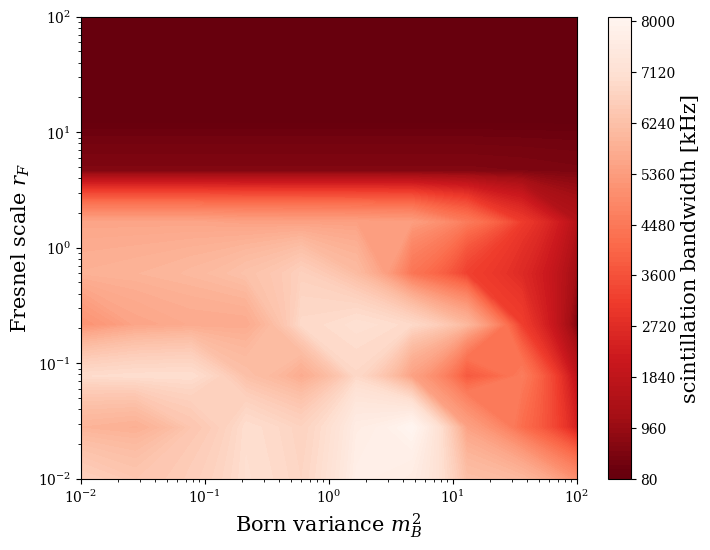

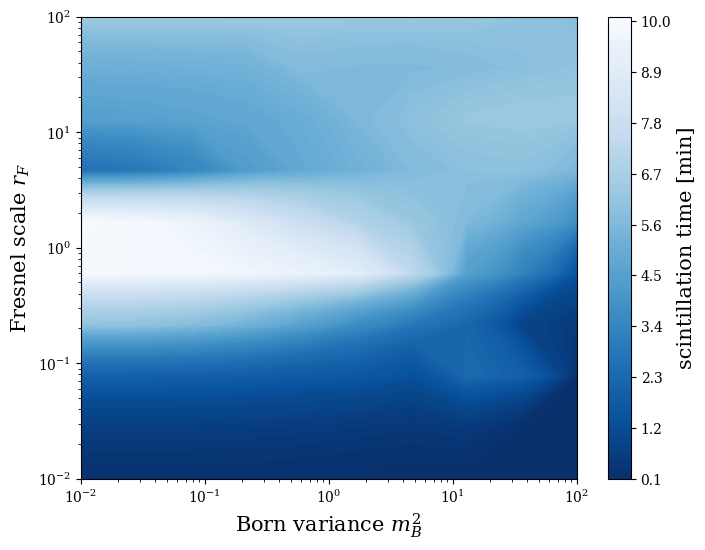

In [181]:
arr = np.average(big_arr, axis=0)
fig = plt.figure(figsize=(8,6))
print(dv*1000)
plt.contourf(mb2vec, rfvec, arr[:,2].reshape(len(mb2vec), len(rfvec)), levels=100, cmap='Reds_r', vmin=dv*1000)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Born variance $m_B^2$', size=15)
plt.ylabel(r'Fresnel scale $r_F$', size=15)
cbar = plt.colorbar(label='scintillation bandwidth [kHz]')
cbar.set_label('scintillation bandwidth [kHz]', size=15)
plt.show()

arr = np.array(arr)
fig = plt.figure(figsize=(8,6))
plt.contourf(mb2vec, rfvec, arr[:,3].reshape(len(mb2vec), len(rfvec)), levels=100, cmap='Blues_r')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Born variance $m_B^2$', size=15)
plt.ylabel(r'Fresnel scale $r_F$', size=15)
cbar = plt.colorbar(label='scintillation time [min]')
cbar.set_label('scintillation time [min]', size=15)
plt.show()

# do this for varying ns / size of screen

In [ ]:
# below FM window is roughly 45-87.5 MHz
# above FM window is roughly 108-250 MHz

sbw_below, st_below, dspec_below = run_sim_acfs(1e-5, )

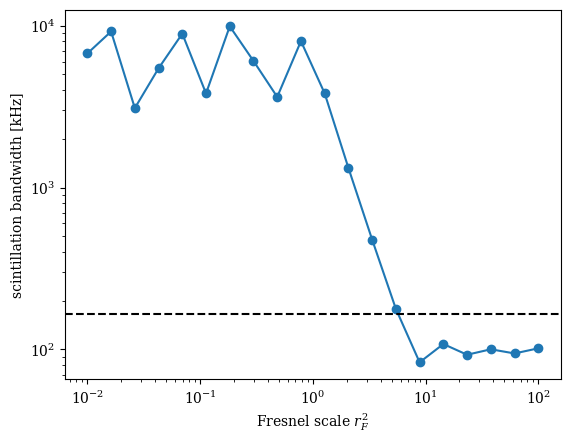

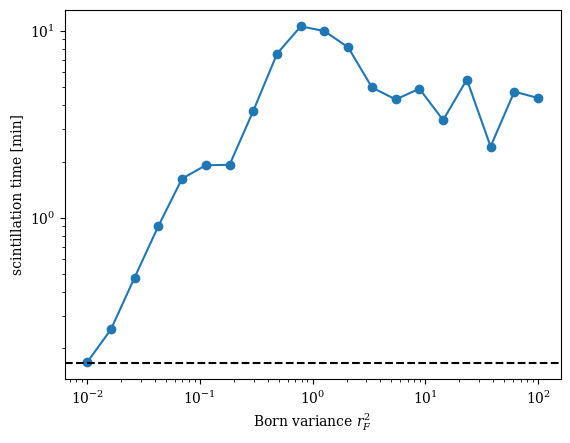

In [ ]:
plt.plot(rfvec, sbwvec, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.axhline(dv*1000, c='k', ls='--')
#plt.axhline((sim.freqs.max()-sim.freqs.min())*1000, c='k', ls='--')
plt.xlabel(r'Born variance $m_B^2$')
plt.xlabel(r'Fresnel scale $r_F$')
plt.ylabel('scintillation bandwidth [kHz]')
plt.show()

plt.plot(rfvec, stvec, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.axhline(dt*60, c='k', ls='--')
#plt.axhline((sim.times.max()-sim.times.min())/60, c='k', ls='--')
plt.xlabel(r'Born variance $r_F^2$')
plt.ylabel('scintillation time [min]')
plt.show()

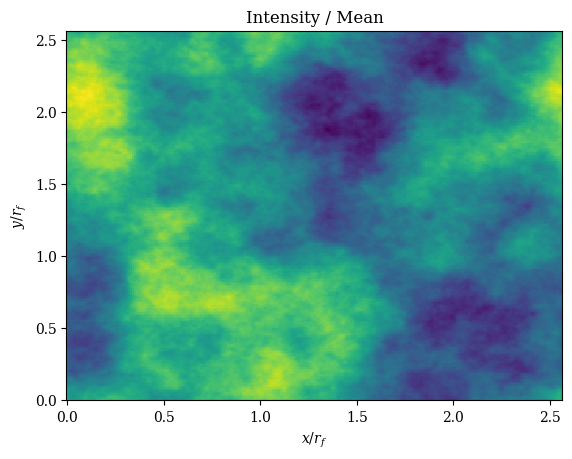

In [98]:
# Plot the observer-side intensity fluctuations in space (at the center frequency)
sim.plot_intensity()

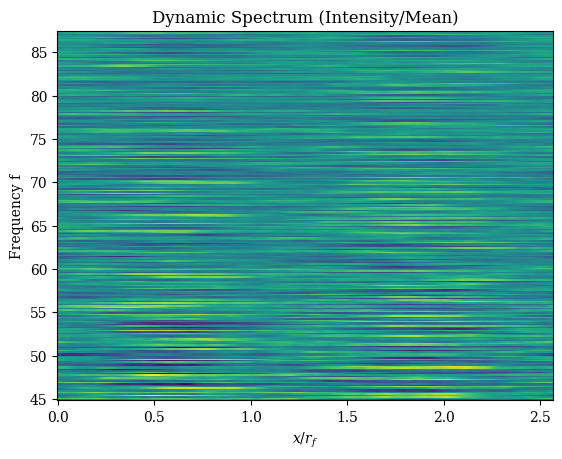

In [99]:
# Plot the dynamic spectrum
sim.plot_dynspec()

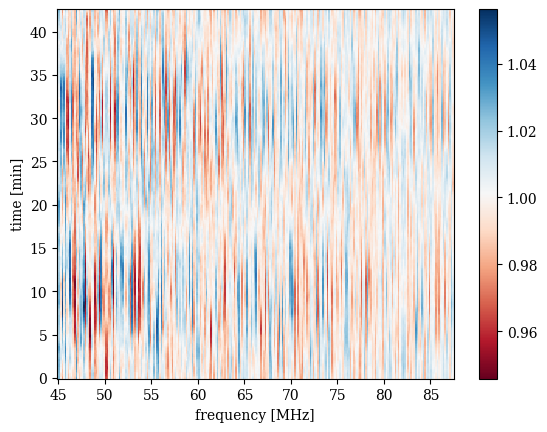

In [100]:
dspec = sim.spi
plt.pcolormesh(sim.freqs, sim.times/60, dspec, cmap='RdBu')
plt.colorbar()
plt.ylabel('time [min]')
plt.xlabel('frequency [MHz]')
plt.show()

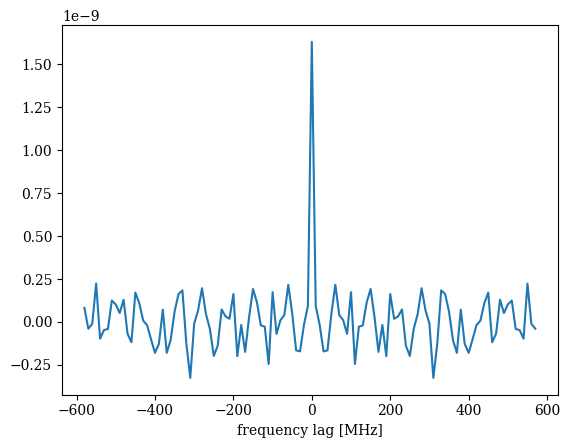

scintillation timescale is 2.08e+02 min


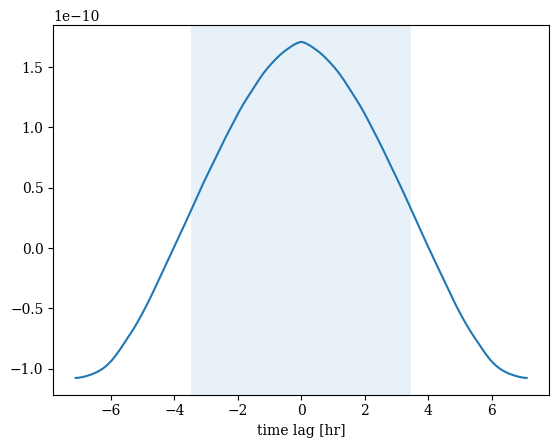

In [10]:
def acf(vec):
    a = []
    for i in range(len(vec)):
        rollvec = np.roll(vec, i)
        a.append(np.dot(vec, rollvec)/len(vec))
    return np.array(a)
def fwhm(x, y):
    w = peak_widths(y, np.where(x==0)[0], rel_height=0.5)[0]
    return w

dspec = sim.spi
spec = np.average(dspec, axis=0)-1
dv = sim.freqs[1]-sim.freqs[0]
plt.plot(np.arange(len(spec))*dt-len(spec)*dt/2, np.roll(acf(spec), len(spec)//2))
plt.xlabel('frequency lag [MHz]')
plt.show()

time = np.average(dspec, axis=1)-1
dt = (sim.times[1]-sim.times[0])/60/60
x = np.arange(len(time))*dt-len(time)*dt/2
y = np.roll(acf(time), len(time)//2)
plt.plot(x, y)
print(f'scintillation timescale is {fwhm(x, y)[0]*dt*60/2:.3} min')
plt.axvspan(x[len(x)//2]-fwhm(x, y)*dt/2, x[len(x)//2]+fwhm(x, y)*dt/2, alpha=0.1, lw=0)
plt.xlabel('time lag [hr]')
plt.show()

In [12]:
print(sim.times/60/60)

[0.00000000e+00 2.77777778e-03 5.55555556e-03 ... 1.42138889e+01
 1.42166667e+01 1.42194444e+01]


Text(0.5, 1.0, 'secondary spectrum')

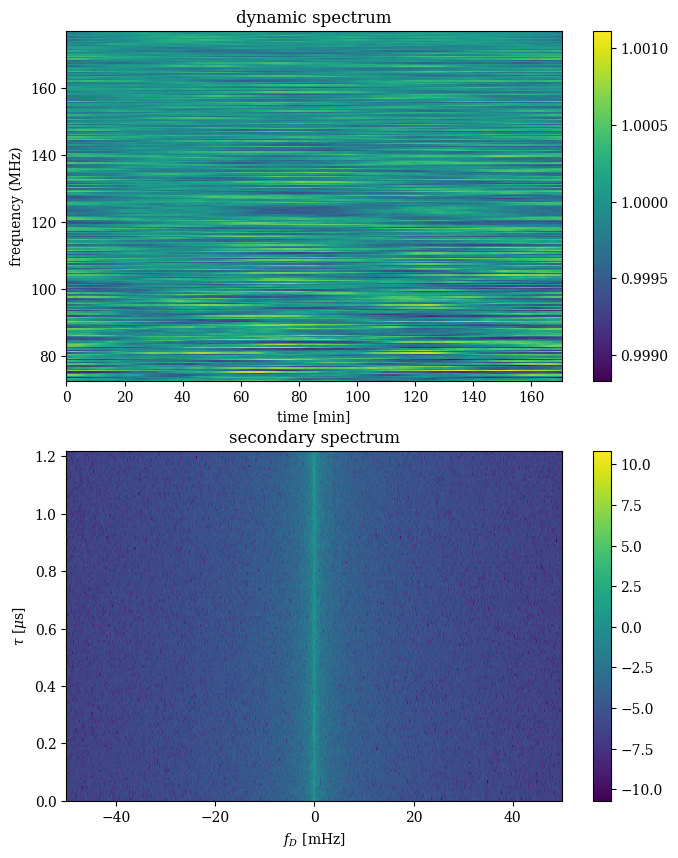

In [11]:
## Define coordinates for conjugate/secondary spectra

time = sim.times * u.s
freq = sim.freqs * u.MHz
fd = THTH.fft_axis(time, u.mHz)
tau = THTH.fft_axis(freq, u.us)

from matplotlib.colors import LogNorm

##Sample spectra from portion of data
plt.figure(figsize=(8, 10))
plt.subplot(211)
plt.imshow(
    dspec[:, :].T,
    origin="lower",
    aspect="auto",
    interpolation='none',
    extent=THTH.ext_find(time.to(u.min), freq[:]),
)
SS = np.fft.fftshift(np.abs(np.fft.fft2(dspec[:, :].T)) ** 2)
plt.xlabel("time [min]")
plt.ylabel("frequency (MHz)")
plt.title("dynamic spectrum")
plt.colorbar()
plt.subplot(212)
plt.imshow(
    np.log10(SS),
    #norm=LogNorm(vmax=1e6, vmin=1e-4),
    origin="lower",
    aspect="auto",
    extent=THTH.ext_find(fd, tau),
    interpolation='none'
)
plt.ylim(0, plt.gca().get_ylim()[1])
#plt.xlim(-1, 1)
plt.colorbar()
plt.xlabel(r"$f_D$ [mHz]")
plt.ylabel(r"$\tau$ [$\mu$s]")
plt.title("secondary spectrum")

(360, 256)
(360, 256)


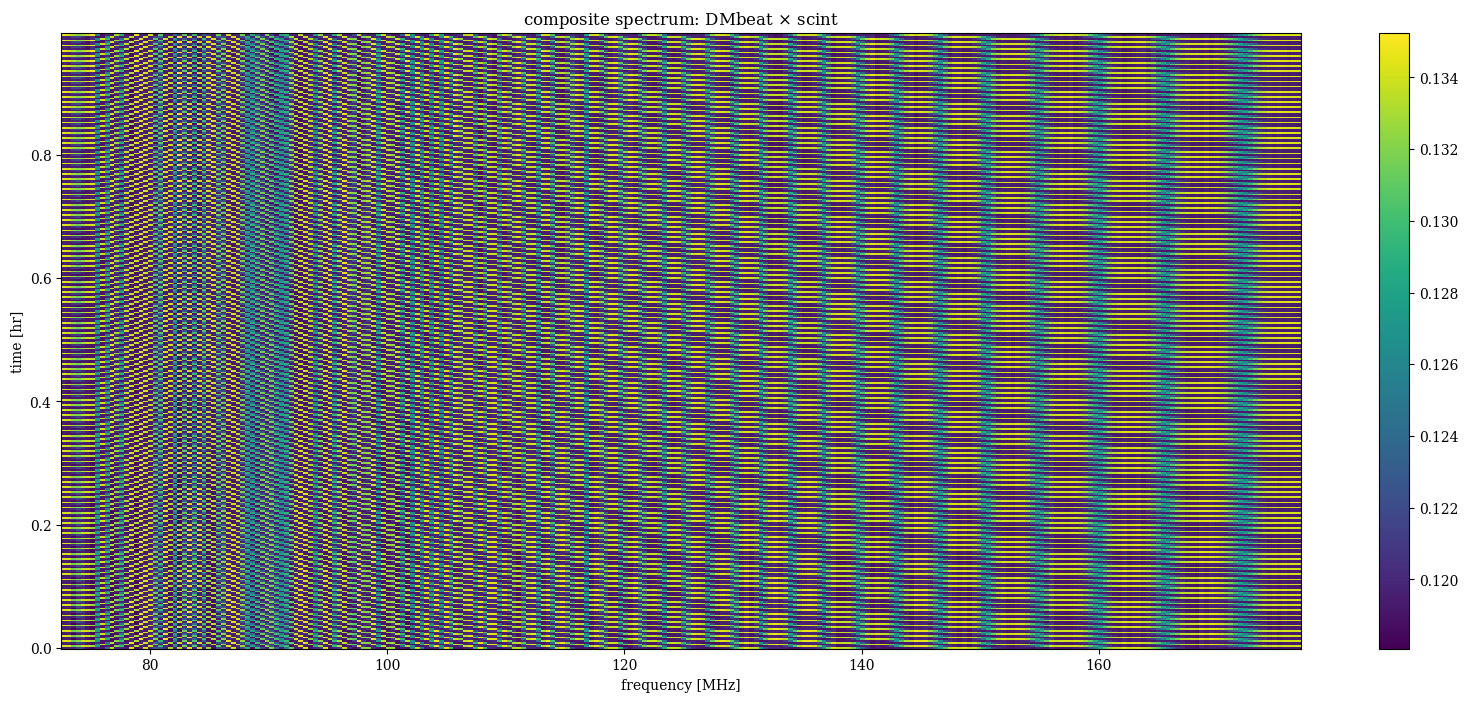

In [195]:
dmbeat = np.load('/Users/user/Desktop/ml-inpaint/DMbeat_spectrum.npy')
print(dmbeat.shape)
print(dspec[:360].shape)
cspec = dmbeat*dspec[:360]
fig = plt.figure(figsize=(20,8))
plt.pcolormesh(sim.freqs, sim.times[:360]/60/60, cspec)
plt.colorbar()
plt.ylabel('time [hr]')
plt.xlabel('frequency [MHz]')
plt.title(r'composite spectrum: DMbeat $\times$ scint')
plt.show()